In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [ ]:
df =pd.read_csv("Data/cleaned_nassau.csv")

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Gross Margin %'],
      dtype='str')

In [12]:
 df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100

In [14]:
print("Total Sales:", df["Sales"].sum())
print("Total Gross Profit:", df["Gross Profit"].sum())
print("Average Gross Margin:", round(df["Gross Margin %"].mean(),2),"%")
print("Total Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())

Total Sales: 141783.63
Total Gross Profit: 93442.79999999999
Average Gross Margin: 66.51 %
Total Orders: 8549
Total Customers: 5044


In [16]:
product_profit = (
    df.groupby("Product Name")[["Sales","Gross Profit"]]
      .sum()
      .sort_values("Gross Profit", ascending=False)
)

product_profit

,Sales,Gross Profit
Product Name,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20
Wonka Bar - Milk Chocolate,26867.75,17443.37
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95
Wonka Bar - Fudge Mallows,24890.40,16593.60
Lickable Wallpaper,7860.00,3930.00
Wonka Gum,597.50,310.70
Everlasting Gobstopper,130.00,104.00
Kazookles,1205.75,92.75


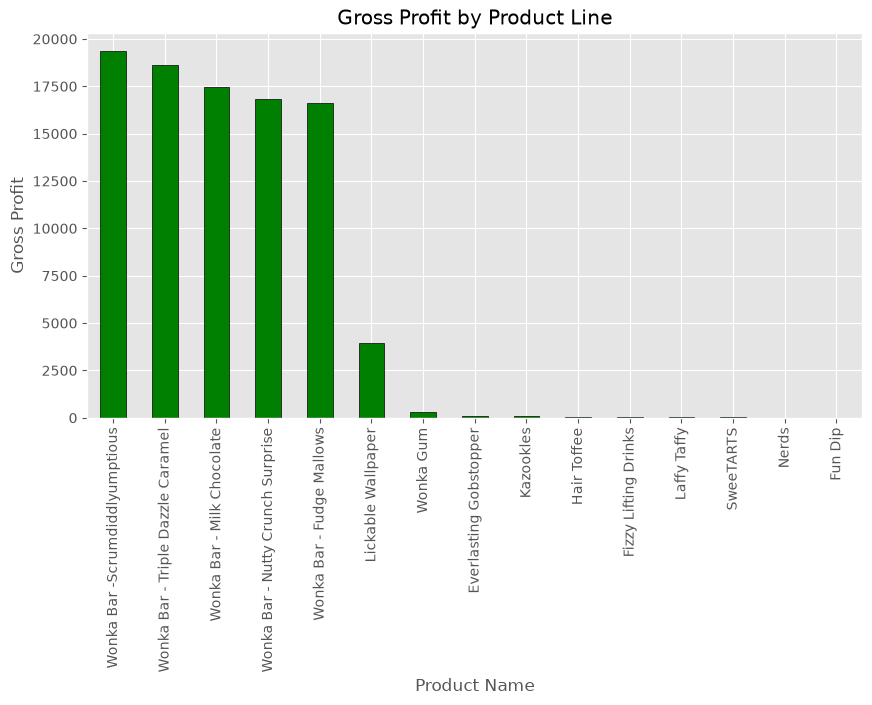

In [21]:
product_profit["Gross Profit"].plot(
    kind="bar",
    figsize=(10,5),
    color="green",
    edgecolor="black"
)

plt.title("Gross Profit by Product Line")
plt.ylabel("Gross Profit")
plt.show()

In [ ]:
#Wonka Bar -Scrumdiddlyumptious genrates the most proftit followed by Wonka Bar - Triple Dazzle Caramel while Fun Dip generates least profit 

In [22]:
top_products = (
    df.groupby("Product Name")["Gross Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64

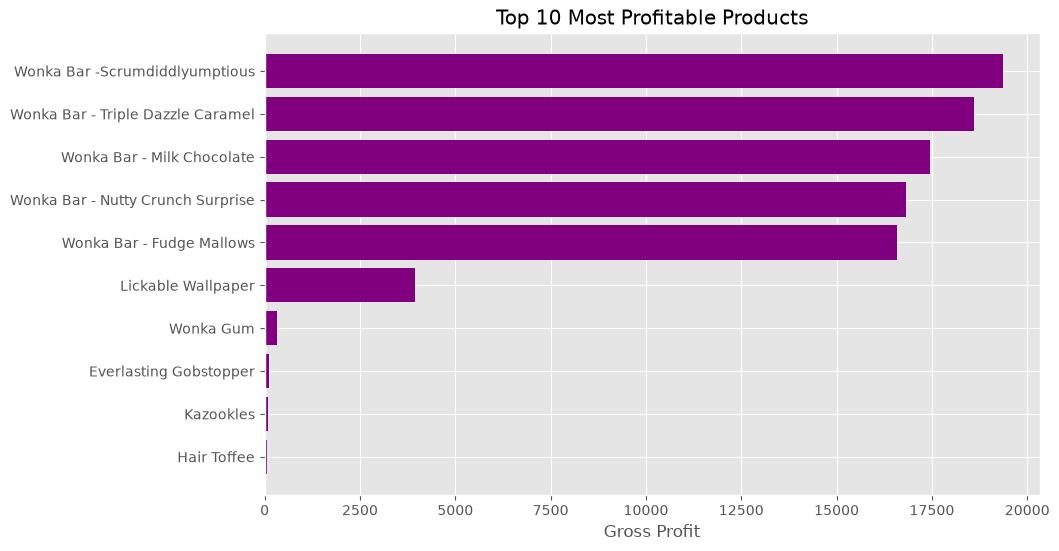

In [24]:
plt.figure(figsize=(10,6))
plt.barh(
    top_products.index,
    top_products.values,
    color="purple"
)
plt.gca().invert_yaxis()
plt.title("Top 10 Most Profitable Products")
plt.xlabel("Gross Profit")
plt.show()

In [25]:
#Wonka Bar -Scrumdiddlyumptious genrates the most gross proftit followed by Wonka Bar - Triple Dazzle Caramel while Hair Toffe generates least gross profit 

In [29]:
bottom_products = (
    df.groupby("Product Name")["Gross Profit"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

bottom_products

Product Name
Fun Dip                      4.80
Nerds                        7.00
SweeTARTS                   28.70
Laffy Taffy                 33.48
Fizzy Lifting Drinks        47.25
Hair Toffee                 59.50
Kazookles                   92.75
Everlasting Gobstopper     104.00
Wonka Gum                  310.70
Lickable Wallpaper        3930.00
Name: Gross Profit, dtype: float64

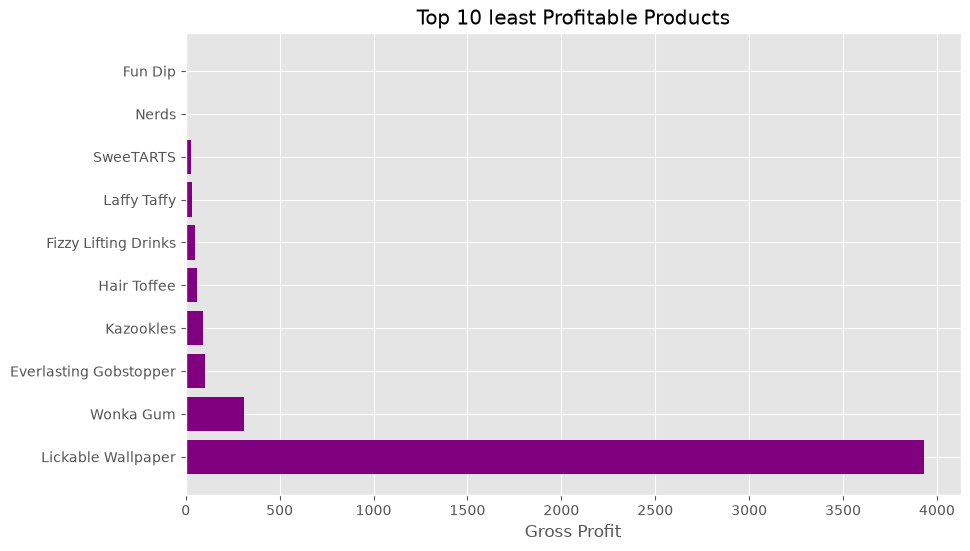

In [31]:
plt.figure(figsize=(10,6))
plt.barh(
    bottom_products.index,
    bottom_products.values,
    color="purple"
)
plt.gca().invert_yaxis()
plt.title("Top 10 least Profitable Products")
plt.xlabel("Gross Profit")
plt.show()

In [32]:
#Fun Dip and Nerds are the products with least gross profit

In [ ]:
#High Sales Low Margin producsts

In [38]:
summary = (
    df.groupby("Product Name")[["Gross Margin %","Sales"]]
      .mean()
      .sort_values("Gross Margin %", ascending=True)
)

summary.head(15)


,Gross Margin %,Sales
Product Name,,
Kazookles,7.692308,12.559896
Fun Dip,40.000000,4.000000
Nerds,46.666667,3.750000
SweeTARTS,46.666667,6.150000
Lickable Wallpaper,50.000000,83.617021
Wonka Gum,52.000000,4.979167
Fizzy Lifting Drinks,60.000000,13.125000
Laffy Taffy,62.311558,5.373000
Wonka Bar - Milk Chocolate,64.923077,12.572649


In [39]:
#Kazookles,Nerds and Fun dip dispite having large amount of sales generate the least gross margin % of 7.692308% for Kazookles 40% for Fun Dip and 46.666667% for Nerds

In [40]:
division = (
    df.groupby("Division")[["Sales","Gross Profit"]]
      .sum()
)

division

,Sales,Gross Profit
Division,,
Chocolate,131692.90,88824.62
Other,9663.25,4333.45
Sugar,427.48,284.73


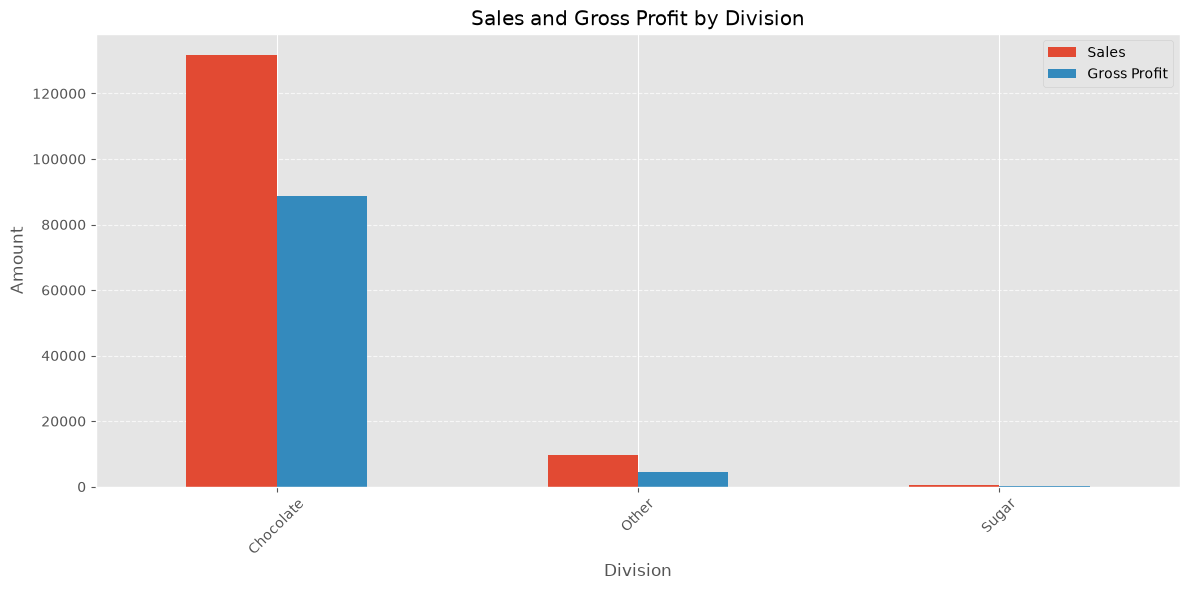

In [48]:
division.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sales and Gross Profit by Division")
plt.xlabel("Division")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [49]:
#chocolate generates the most sales and most gross profit followed by other while sugar generates the least gross profit and and least amount sales  

In [54]:
region_profit = (
    df.groupby("Region")[["Sales","Gross Profit"]]
      .sum()
)

region_profit

,Sales,Gross Profit
Region,,
Atlantic,41197.24,26973.70
Gulf,22247.26,14700.67
Interior,32037.60,21282.49
Pacific,46301.53,30485.94


In [53]:
state_profit = (
    df.groupby("State/Province")[["Sales", "Gross Profit"]]
      .sum()
      .sort_values("Gross Profit", ascending=False)
      .head(10)
)

state_profit

,Sales,Gross Profit
State/Province,,
California,27917.40,18479.42
New York,15541.03,10222.44
Texas,13416.09,8909.53
Pennsylvania,8027.03,5225.47
Washington,6921.15,4566.64
Illinois,6898.96,4557.68
Ohio,6768.95,4413.03
Florida,4804.02,3207.11
North Carolina,3450.86,2331.16


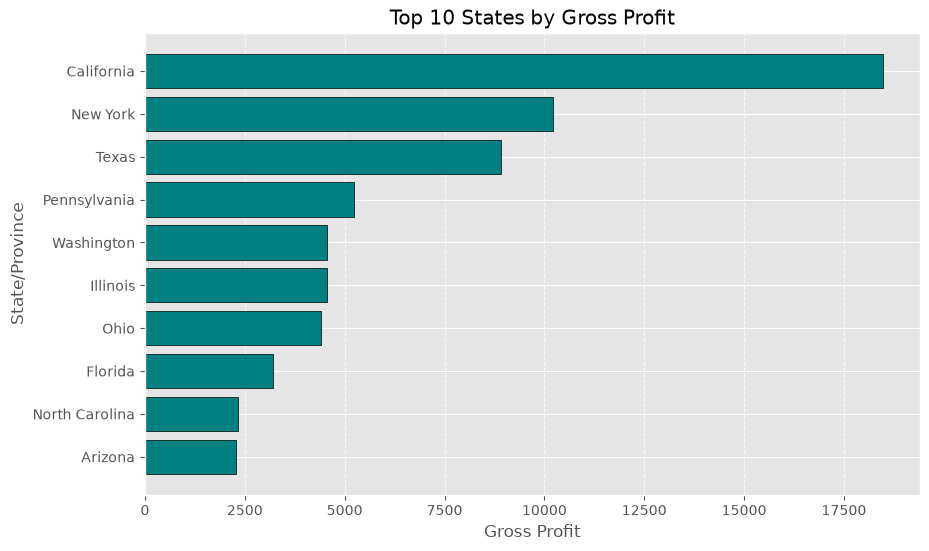

In [57]:
plt.figure(figsize=(10,6))

plt.barh(
    state_profit.index,
    state_profit["Gross Profit"],
    color="teal",
    edgecolor="black"
)

plt.title("Top 10 States by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("State/Province")
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Highest profit at the top
plt.gca().invert_yaxis()

plt.show()

In [ ]:
#

In [58]:
customer_profit = (
    df.groupby("Customer ID")["Gross Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

customer_profit

Customer ID
131807    256.60
115238    249.30
122336    193.44
164756    166.42
139675    134.40
151799    132.52
124163    127.95
100111    125.93
164770    122.50
119508    122.34
Name: Gross Profit, dtype: float64

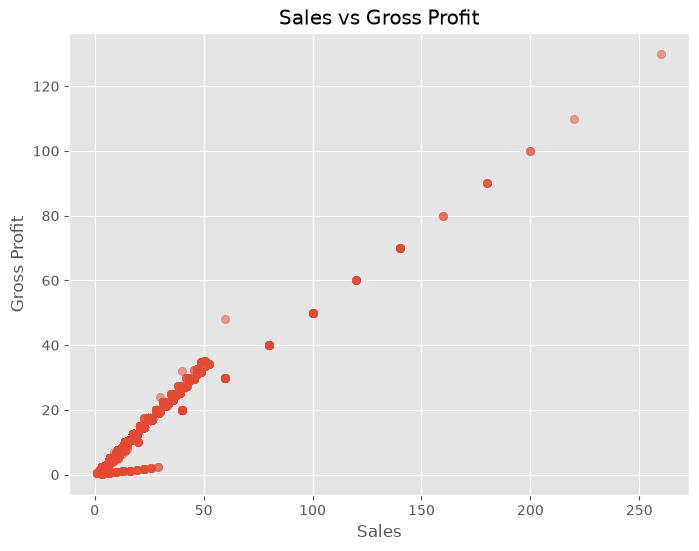

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"], df["Gross Profit"], alpha=0.5)

plt.title("Sales vs Gross Profit")
plt.xlabel("Sales")
plt.ylabel("Gross Profit")

plt.show()

In [60]:
margin = (
    df.groupby("Division")["Gross Margin %"]
      .mean()
      .sort_values(ascending=False)
)

margin

Division
Chocolate    67.458162
Sugar        57.689001
Other        37.672457
Name: Gross Margin %, dtype: float64